# **Welcome to the Python Notebook for processing and analyzing Hydrogen data in the Univeristy at Buffalo Organic and Stable Isotope Biogeochemistry Laboratory! 💦**

>**How to use this code:** <br>
To run this script, click the **"Run" (play button)** for each cell in order. These chunks of code are divided into steps where the user may want to debug as they process their dataset.
>
>This Jupyter Notebook is designed to use the 20260529_OSIBL Data Template.xlsx. If you are using an older version of the spread sheet, pay attention to the names of the tabs and column headers to confirm you are calling for the correct information. Using other spreadsheet or data formats will likely not work because many functions reference the standardized column names.



*Adapted by - Leone L. Jacobson from John Michael Aguilar, Kurt R. Lindberg, Hannah Holtzman, & Rebecca G. Topness <br>
Last Edited - 02/02/2026*



---


## Part 1: Set-up 🧰


---



In [14]:
# Import necessary Python packages we'll use throughout this script
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import packages that will be needed
import json

# import pyleoclim as pyleo
import seaborn.objects as so


# from pylipd.lipd import LiPD
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch


## FROM KRL: Also import matplotlib.pyplot for additional figure-making capabilities
import matplotlib.cm as cm
from matplotlib import ticker

plt.rcParams['pdf.fonttype'] = 42  # changes font type so that vector graphics software (i.e. Adobe Illustrator) recognizes text
plt.rcParams['font.family'] = "Arial"  # changes font type to Arial; Illustrator on Windows doesn't work well with default Pyplot font



---

## Part 2: Load in the dataset ⌛

---



In [15]:
# Import the data itself
#data = pd.read_csv("C:\\Users\\leone\\OneDrive - University at Buffalo\\Red Pond\\GCIRMS\\samples_according _to_sequence.csv")
# -- Load the data --
df = pd.read_excel('/Users/leone/OneDrive - University at Buffalo/Red Pond/20251204_LLJ_RedPond_OSIBL  (version 1).xlsx', sheet_name= 'ASE-GC-IRMS', nrows=38)
# -- Load the data --
wax_df2 = pd.read_excel('/Users/leone/OneDrive - University at Buffalo/Red Pond/20251204_LLJ_RedPond_OSIBL  (version 1).xlsx', sheet_name= 'ASE-GC-IRMS', nrows=38)



---

## Part 3: sort data by age (can sub to sort by depth too)

---



In [16]:
# --- 1. Sort by age so the line connects chronologically ---
df_sorted = df.sort_values("Age (Cal. Yrs BP)")



---


## Part 4: Create a stacked plot of Average Chain Length, Carbon Preference Index, and Fractional Abundance 


---



In [17]:
# -- isolated and normalize the Cxx chain lengths concentrations --
# Select only the columns you want to normalize
selected_columns = ['Midpoint Composite Depth (cm)','Age (Cal. Yrs BP)','C20_conc','C22_conc','C24_conc','C26_conc','C28_conc','C30_conc','C32_conc']
norm_columns = ['C20_conc','C22_conc','C24_conc','C26_conc','C28_conc','C30_conc','C32_conc']

# Normalize the selected columns
Acids_normalized = wax_df2[selected_columns].copy()
Acids_normalized[norm_columns] = wax_df2[norm_columns].div(wax_df2[norm_columns].sum(axis=1), axis=0)
Acids_normalized

# -- melt the dataframe to long format for easier plotting -- If your data does not look correct, it most likely is the melted dataframe that is the issue and double check your data
# Select only the columns you want to include in the melted DataFrame for plotting fractional abundance data
selected_columns = ['Midpoint Composite Depth (cm)', 'C20_conc','C22_conc','C24_conc','C26_conc','C28_conc','C30_conc','C32_conc']

# Melt the DataFrame with selected columns
melted_df = pd.melt(Acids_normalized[selected_columns], id_vars=['Midpoint Composite Depth (cm)'], var_name='Chain Length', value_name='FAME_FracAbund')
melted_df = (
    melted_df
    .groupby(["Midpoint Composite Depth (cm)", "Chain Length"], as_index=False)
    .agg({"FAME_FracAbund": "mean"})   # or sum()
)

# wax_df2 = wax_df2.sort_values("Midpoint Composite Depth (cm)")
wax_df2["Midpoint Composite Depth (cm)"].duplicated().sum()
wax_df2[
    wax_df2["Midpoint Composite Depth (cm)"].between(250, 290)
]

,Sample Name,Lab ID,Sample Depth Bottom (cm),Sample Depth Top (cm),Midpoint Depth (cm),Midpoint Composite Depth (cm),Age - 2σ,Age (Cal. Yrs BP),Age + 2σ,Date Pre Freeze Drying,...,C28%,C30%,C32%,C20_conc,C22_conc,C24_conc,C26_conc,C28_conc,C30_conc,C32_conc
16,21RP-1-2B-104-105cm,LLJ017,105,104,104.5,250.5,NaN,5932,NaN,NaN,...,0.233318,0.084020,0.027722,0.052860,0.107828,0.158320,0.335931,0.233318,0.084020,0.027722
17,21RP-1-3A-73-74cm,LLJ018,74,73,73.5,262.5,NaN,6233,NaN,NaN,...,0.221273,0.083766,0.024779,0.047149,0.121767,0.179403,0.321863,0.221273,0.083766,0.024779
18,21RP-1-3A-79-80cm,LLJ019,80,79,79.5,268.5,NaN,6511,NaN,NaN,...,0.206217,0.058279,0.025336,0.057225,0.157950,0.163156,0.331837,0.206217,0.058279,0.025336
19,21RP-1-3A-85-86cm,LLJ020,86,85,85.5,274.5,NaN,6793,NaN,NaN,...,0.220428,0.061741,0.023215,0.042361,0.092543,0.120971,0.438742,0.220428,0.061741,0.023215
20,21RP-1-3A-91-92cm,LLJ021,92,91,91.5,280.5,NaN,7090,NaN,NaN,...,0.207498,0.049074,0.029943,0.051480,0.119343,0.144374,0.398288,0.207498,0.049074,0.029943
21,21RP-1-3A-97-98cm,LLJ022,98,97,97.5,286.5,NaN,7389,NaN,NaN,...,0.211978,0.073787,0.020270,0.051915,0.107817,0.137377,0.396856,0.211978,0.073787,0.020270


<Figure size 800x600 with 0 Axes>

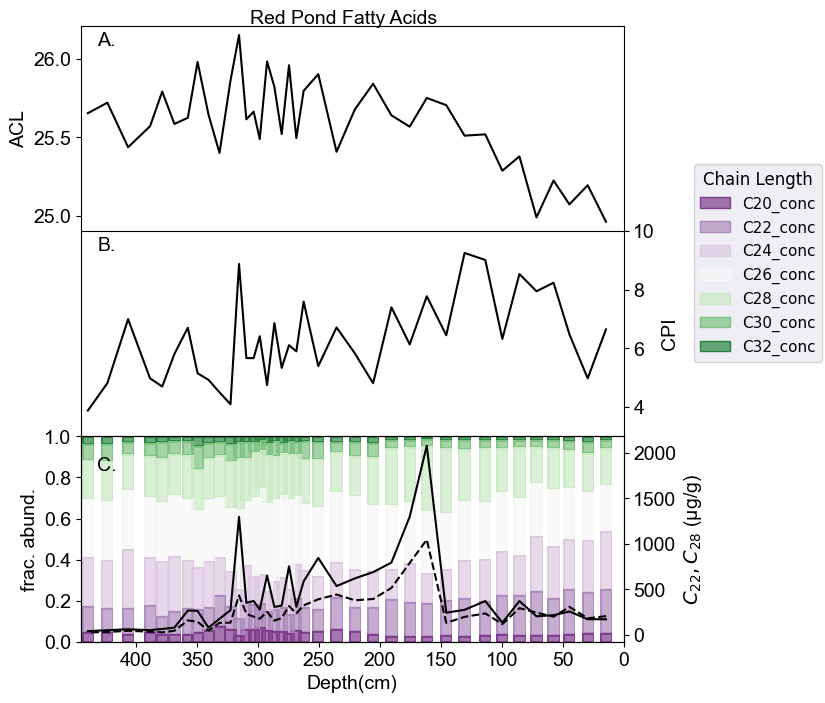

In [67]:
plt.figure(1)
fig, axs = plt.subplots(3, 1,sharex=False)
fig.set_size_inches(7, 8) 

# Generate equally spaced colors from 'PRGn' colormap excluding the white color
colors = [cm.PRGn(i / (8 - 1)) for i in range(8)]

# Calculate the position for letter label in each subplot
x_pos = 0.03  # Adjust the x-coordinate as needed
y_pos = 0.97   # Adjust the y-coordinate as needed


ax = axs[0]
ax.plot(wax_df2['Midpoint Composite Depth (cm)'],wax_df2['ACL'],c='k')
ax.set_xlim(445,0)
ax.set_xlabel(None)
ax.set_ylabel('ACL')
ax.spines['bottom'].set_visible(False)
# Remove grid lines and tick labels
ax.grid(False)
ax.set_xticks([])
ax.patch.set_alpha(0)
#add a panel label to the top left of the plot
ax.text(x_pos, y_pos, f"A.", transform=ax.transAxes,
        fontsize=14, va='top', ha='left')


ax = axs[1]
ax.plot(wax_df2['Midpoint Composite Depth (cm)'],wax_df2['CPI'],c='k')
ax.set_xlim(445,0)
ax.set_xlabel(None)
ax.set_ylim(3,10)
ax.spines['bottom'].set_visible(False)
ax.set_ylabel('CPI')
# Remove grid lines and tick labels
ax.grid(False)
ax.set_xticks([])
ax.patch.set_alpha(0)
# Move y-axis ticks and labels to the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')
#add a panel label to the top left of the plot
ax.text(x_pos, y_pos, f"B.", transform=ax.transAxes,
        fontsize=14, va='top', ha='left')


ax_twin2 = axs[2].twinx()
ax_twin2.plot(wax_df2['Midpoint Composite Depth (cm)'],(wax_df2['C28 mass (ng)']/1000)/wax_df2["Dry Sediment (g)"],c='k')
ax_twin2.plot(wax_df2['Midpoint Composite Depth (cm)'],(wax_df2['C22 mass (ng)']/1000)/wax_df2["Dry Sediment (g)"],c='k',linestyle='--')
ax_twin2.set_ylabel('$C_{22},  C_{28}$ (µg/g)')

# Filter out NaNs before plotting
# depth_valid_28 = wax_df2['Midpoint Composite Depth (cm)'][wax_df2['C28_conc'].notna()]
# C28conc_valid = wax_df2['C28_conc'].dropna()

# depth_valid_22 = wax_df2['Midpoint Composite Depth (cm)'][wax_df2['C22_conc'].notna()]
# C22conc_valid = wax_df2['C22_conc'].dropna()


#define the seaborn object bar plot
fa=(
    so.Plot(melted_df, x="Midpoint Composite Depth (cm)", y="FAME_FracAbund", color="Chain Length")
    .add(so.Bar(width=2), so.Stack()).scale(color="PRGn",alpha=1)
    .share(y=False)
    .label(x='Depth(cm)', y="frac. abund.") 
)


ax = axs[2]
ax.set_xlim(445,0)
ax.set_ylim(0,1)
ax.set_xlabel('Depth(cm)')
# Remove grid lines
ax.grid(False)
ax.patch.set_alpha(0)
# Add a title to the entire figure
fig.suptitle('Red Pond Fatty Acids', fontsize=14, y= 0.90)

#ET can't get these ax_full commands to work.
# ax_full = fig.add_subplot(111,zorder=0)
# ax_full.set_axis_off()
# ax_full.set_xlim(441,0)

# #draw a rectangle to highlight specific time span in the plot
# ax_full.axvspan(800,516,facecolor='gray',ec=None,zorder=-1,alpha=0.1)
# ax_full.axvspan(447,431,facecolor='gray',ec=None,zorder=-1,alpha=0.1)


#add a panel label to the top left of the plot
ax.text(x_pos, .9, f"C.", transform=ax.transAxes,
        fontsize=14, va='top', ha='left')

fa_plot = fa.on(ax).plot()

colors = plt.cm.PRGn(np.linspace(0,1,8))
labels = melted_df['Chain Length'].unique()

      
plt.subplots_adjust(wspace=-1, hspace=0)
plt.show()




---


## Part 5: Create a stacked time series plot of each chain length, using the orginal xslx
 NOT THE MELTED DF


---

Text(0.5, 0, 'Age (Cal. Yrs BP)')

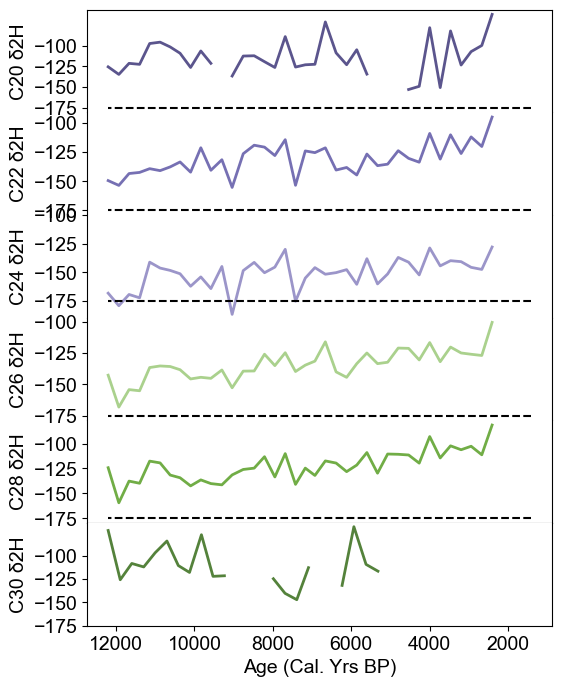

In [34]:
fig, axs = plt.subplots(6,1)
# set figure size
plt.rcParams['figure.figsize'] = [8,6]  
# fig, axs = plt.subplots(3,2)  # thinner plot


#C20 plot
ax = axs[0]
# --- 2. Plot the chronological line (one continuous line) ---
ax.plot(df_sorted["Age (Cal. Yrs BP)"], df_sorted["C20 δ2H (‰)"],
         color="#5B558D", alpha=1, linewidth=2)
         #label="Chronological connection")
ax.hlines(y=-175, xmin=0, xmax=df_sorted["Age (Cal. Yrs BP)"].max(), colors="black", linestyles='dashed', label='-150‰ Reference Line')
ax.set_ylabel("C20 δ2H")
ax.spines['bottom'].set_visible(False)
ax.set_xticklabels('')
ax.set_xlabel('')
ax.set_yticks(ticks=[-100,-125,-150,-175])
#ax.set_title("C20 δ2H vs Age (Connected by Age, Colored by Sequence)")
ax.invert_xaxis()

#create a stacked plot for C22
ax = axs[1]
ax.plot(df_sorted["Age (Cal. Yrs BP)"], df_sorted["C22 δ2H (‰)"],
         color="#7670b3", alpha=1, linewidth=2)
         #label="Chronological connection")
ax.hlines(y=-175, xmin=0, xmax=df_sorted["Age (Cal. Yrs BP)"].max(), colors="black", linestyles='dashed', label='-150‰ Reference Line')
ax.set_ylabel("C22 δ2H")
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticklabels('')
ax.set_xlabel('')
ax.set_yticks(ticks=[-100,-125,-150,-175])
ax.invert_xaxis()


#create a stacked plot for C24
ax = axs[2]
ax.plot(df_sorted["Age (Cal. Yrs BP)"], df_sorted["C24 δ2H (‰)"],
         color="#9b95c9", alpha=1, linewidth=2)
         #label="Chronological connection")
ax.hlines(y=-175, xmin=0, xmax=df_sorted["Age (Cal. Yrs BP)"].max(), colors="black", linestyles='dashed', label='-150‰ Reference Line')
ax.set_ylabel("C24 δ2H")
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticklabels('')
ax.set_xlabel('')
ax.set_yticks(ticks=[-100,-125,-150,-175])
ax.invert_xaxis()


#create a stacked plot for C26
ax = axs[3]
ax.plot(df_sorted["Age (Cal. Yrs BP)"], df_sorted["C26 δ2H (‰)"],
         color="#aad18d", alpha=1, linewidth=2)
         #label="Chronological connection")
ax.hlines(y=-175, xmin=0, xmax=df_sorted["Age (Cal. Yrs BP)"].max(), colors="black", linestyles='dashed', label='-150‰ Reference Line')
ax.set_ylabel("C26 δ2H")
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticklabels('')
ax.set_xlabel('')
ax.set_yticks(ticks=[-100,-125,-150,-175])
ax.invert_xaxis()


#create a stacked plot for C28
ax = axs[4]
ax.plot(df_sorted["Age (Cal. Yrs BP)"], df_sorted["C28 δ2H (‰)"],
         color="#71ad46", alpha=1, linewidth=2)
         #label="Chronological connection") 
ax.hlines(y=-175, xmin=0, xmax=df_sorted["Age (Cal. Yrs BP)"].max(), colors="black", linestyles='dashed', label='-150‰ Reference Line') 
ax.set_ylabel("C28 δ2H")
ax.spines['top'].set_visible(False)
ax.set_yticks(ticks=[-100,-125,-150,-175])
#flip x axis
ax.invert_xaxis()

#create a stacked plot for C30
ax = axs[5]
ax.plot(df_sorted["Age (Cal. Yrs BP)"], df_sorted["C30 δ2H (‰)"],
         color="#54823B", alpha=1, linewidth=2)
         #label="Chronological connection")  
ax.set_ylabel("C30 δ2H")
ax.spines['top'].set_visible(False)
ax.set_yticks(ticks=[-100,-125,-150,-175])


plt.gca().invert_xaxis()
# Final plot adjustments
#remove space between subplots
plt.subplots_adjust(hspace=0 , wspace=0)
plt.xlabel("Age (Cal. Yrs BP)")




---


## Part 6: Chain Length d2H Value


---

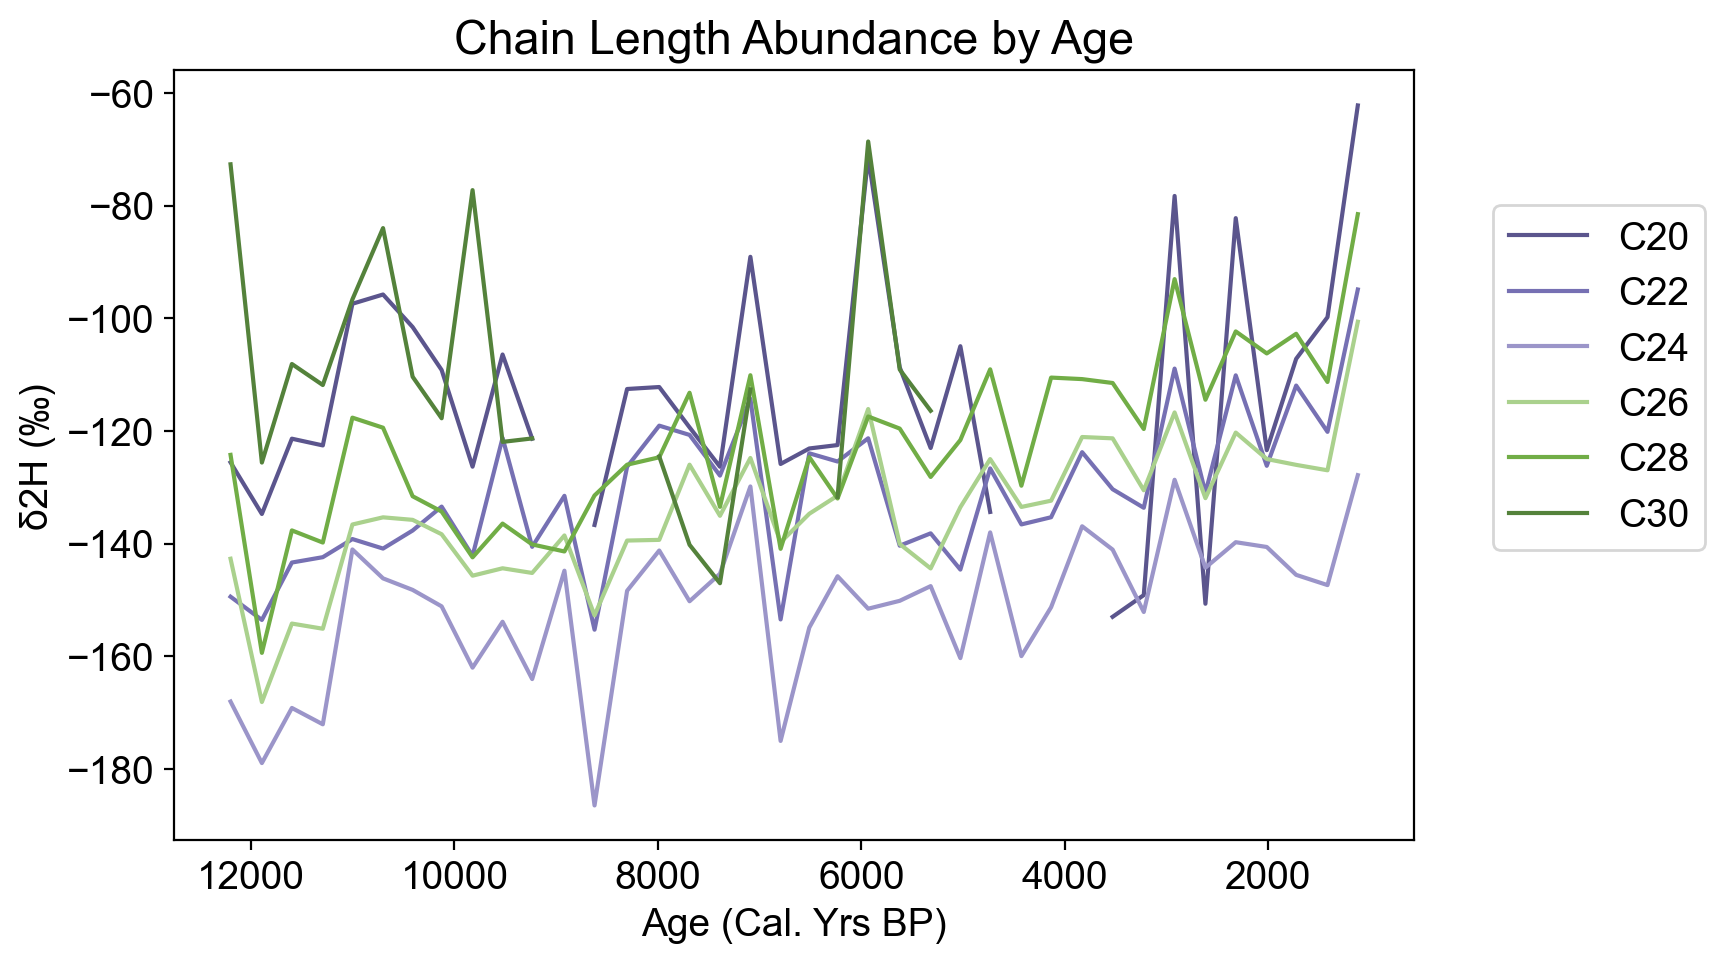

In [38]:
#Plot all even chain lengths on the same plot with different colors and a legend
plt.figure(figsize=[8,5],dpi=200)
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C20 δ2H (‰)'], c="#5B558D", alpha=1, label= "C20")
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C22 δ2H (‰)'],c="#7670b3", alpha=1, label= "C22")
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C24 δ2H (‰)'],c="#9b95c9", alpha=1, label= "C24")
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C26 δ2H (‰)'],c="#aad18d", alpha=1, label= "C26")
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C28 δ2H (‰)'],c="#71ad46", alpha=1, label= "C28")
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C30 δ2H (‰)'],c="#54823B", alpha=1, label= "C30")
plt.gca().invert_xaxis()
plt.xlabel('Age (Cal. Yrs BP)')
plt.ylabel('δ2H (‰)')
plt.title("Chain Length Abundance by Age")
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 0.85))
plt.show()

---


## Part 7: Chain Length d2H Value with Uncertainity


---

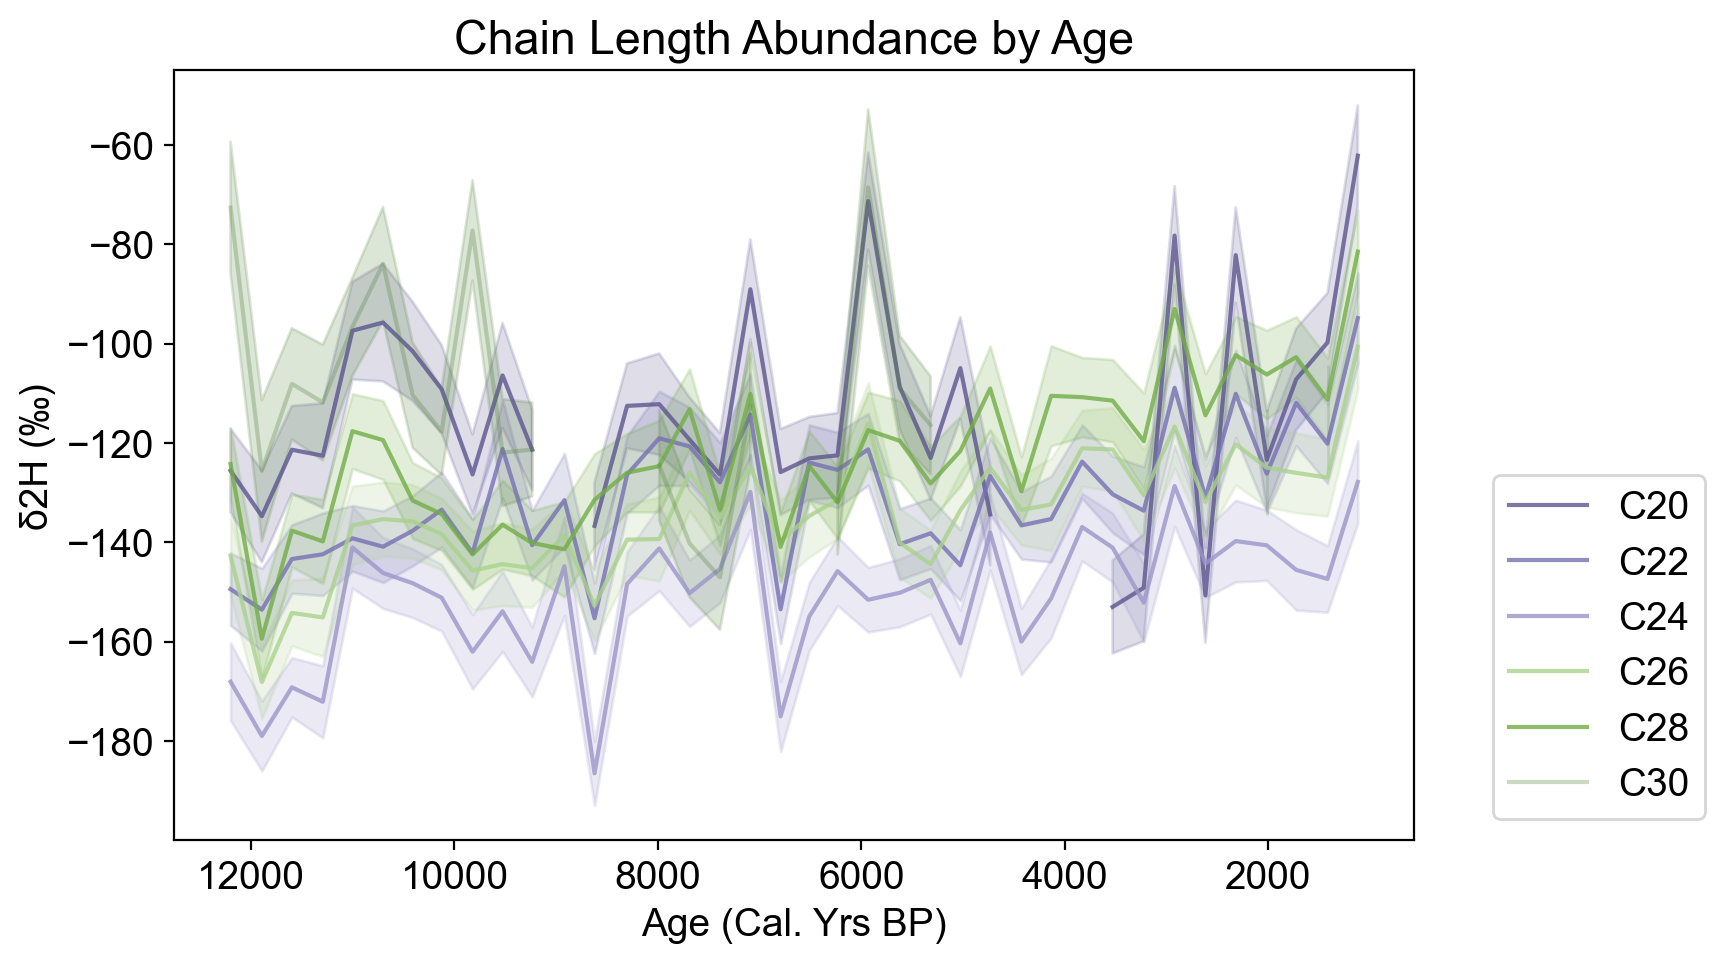

In [37]:
#Plot all even chain lengths on the same plot with uncertainty 

#Create time series plot of all even chain lengthes with uncertainty over Age of the sediment to visualize any possible trends between chain lengths
plt.figure(figsize=[8,5],dpi=200)
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C20 δ2H (‰)'],c="#5B558D", alpha=0.8, label= "C20")
plt.fill_between(df_sorted['Age (Cal. Yrs BP)'],df_sorted["C20 δ2H (‰)"]- df_sorted["C20 Total Uncertainty (‰)"], df_sorted["C20 δ2H (‰)"]+ df_sorted["C20 Total Uncertainty (‰)"],
                 color='#5B558D',
                 alpha=0.2)
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C22 δ2H (‰)'],c="#7670b3", alpha=0.8, label= "C22")
plt.fill_between(df_sorted['Age (Cal. Yrs BP)'],df_sorted["C22 δ2H (‰)"]- df_sorted["C22 Total Uncertainty (‰)"], df_sorted["C22 δ2H (‰)"]+ df_sorted["C22 Total Uncertainty (‰)"],
                 color='#7670b3',
                 alpha=0.2)
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C24 δ2H (‰)'],c="#9b95c9", alpha=0.8, label= "C24")
plt.fill_between(df_sorted['Age (Cal. Yrs BP)'],df_sorted["C24 δ2H (‰)"]- df_sorted["C24 Total Uncertainty (‰)"], df_sorted["C24 δ2H (‰)"]+ df_sorted["C24 Total Uncertainty (‰)"],
                 color='#9b95c9',
                 alpha=0.2)
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C26 δ2H (‰)'],c="#aad18d", alpha=0.8, label= "C26")
plt.fill_between(df_sorted['Age (Cal. Yrs BP)'],df_sorted["C26 δ2H (‰)"]- df_sorted["C26 Total Uncertainty (‰)"], df_sorted["C26 δ2H (‰)"]+ df_sorted["C26 Total Uncertainty (‰)"],
                 color='#aad18d',
                 alpha=0.2)
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C28 δ2H (‰)'],c="#71ad46", alpha=0.8, label= "C28")
plt.fill_between(df_sorted['Age (Cal. Yrs BP)'],df_sorted["C28 δ2H (‰)"]- df_sorted["C28 Total Uncertainty (‰)"], df_sorted["C28 δ2H (‰)"]+ df_sorted["C28 Total Uncertainty (‰)"],
                 color='#71ad46',
                 alpha=0.2)
plt.plot(df_sorted['Age (Cal. Yrs BP)'],df_sorted['C30 δ2H (‰)'],c="#54823B", alpha=0.3, label= "C30")
plt.fill_between(df_sorted['Age (Cal. Yrs BP)'],df_sorted["C30 δ2H (‰)"]- df_sorted["C30 Total Uncertainty (‰)"], df_sorted["C30 δ2H (‰)"]+ df_sorted["C30 Total Uncertainty (‰)"],
                 color='#54823B',
                 alpha=0.2)
plt.xlabel('Age (Cal. Yrs BP)')
plt.gca().invert_xaxis()
plt.ylabel('δ2H (‰)')
plt.title("Chain Length Abundance by Age")
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 0.5))
plt.show() 


---
## Part 8: Chain length d2H Value of Certain Chain Lengths (replace the number after C)
---

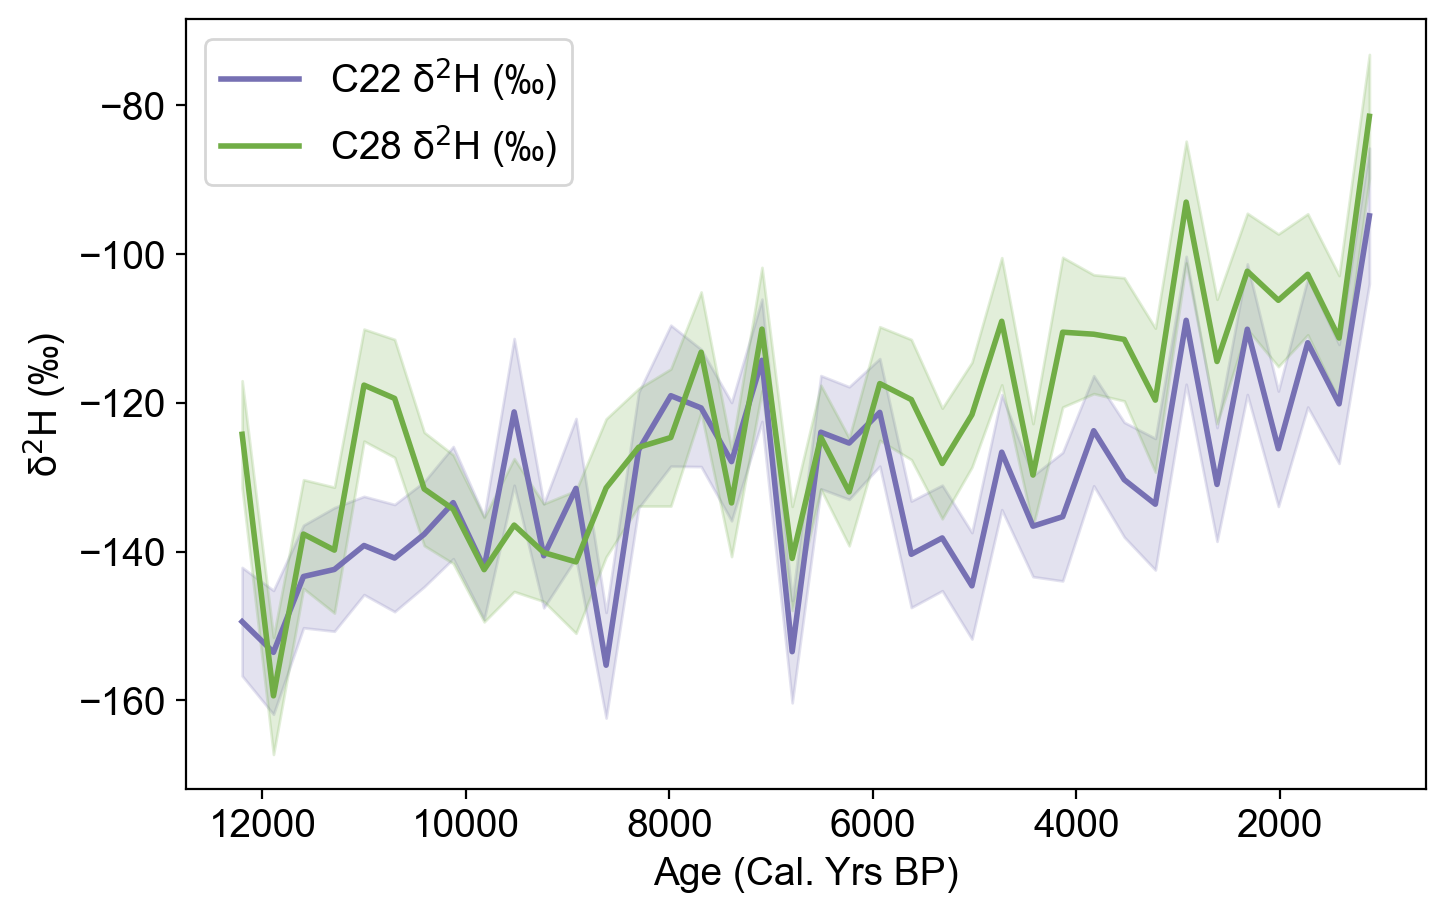

In [ ]:
# -- Plot the figure --
plt.figure(figsize=(8, 5), dpi=200)
# plt.rcParams['font.size']=14

#c22
plt.plot(df_sorted["Age (Cal. Yrs BP)"], df_sorted["C22 δ2H (‰)"],
         color="#7670b3", linewidth=2,
         label="C22 δ$^2$H (‰)") 
plt.fill_between(df_sorted['Age (Cal. Yrs BP)'],df_sorted["C22 δ2H (‰)"]- df_sorted["C22 Total Uncertainty (‰)"], df_sorted["C22 δ2H (‰)"]+ df_sorted["C22 Total Uncertainty (‰)"],
                 color='#7670b3',
                 alpha=0.2)

  
#c28
plt.plot(df_sorted["Age (Cal. Yrs BP)"], df_sorted["C28 δ2H (‰)"],
         color="#71ad46", linewidth=2,
         label="C28 δ$^2$H (‰)")
plt.fill_between(df_sorted['Age (Cal. Yrs BP)'],df_sorted["C28 δ2H (‰)"]- df_sorted["C28 Total Uncertainty (‰)"], df_sorted["C28 δ2H (‰)"]+ df_sorted["C28 Total Uncertainty (‰)"],
                 color='#71ad46',
                 alpha=0.2)   



#add shaded intervals during rapid wamring periods (11.7)
#plt.axvspan(11700, 11600, color='gray', alpha=0.3)

#add shaded intervals during rapid wamring periods (8.0)
#plt.axvspan(8100, 7900, color='gray', alpha=0.3)

#add shaded intervals during rapid wamring periods (0.2)
#plt.axvspan(200, 0, 
#            color='gray', 
#            alpha=0.3)

#figure parameters
#plt.title("δ2H vs Age (C22 + C28)")
plt.xlabel('Age (Cal. Yrs BP)')
plt.ylabel(r'δ$^2$H (‰)')
plt.legend()
plt.gca().invert_xaxis()
plt.show()

___
## Correlogram by KL
___

In [24]:
# load in packages needed
#leafwaxtools is a package made/modified by Kurt Lindberg. 
# In order to create a correlagram you need to download leafwaxtools from github and import it into your script.
# you can download leafwaxtools from github here:https://github.com/kurtlindberg/leafwaxtools
# 
'''
leafwaxtools.Isotope().corr_rvals()
'''

#Load in packages
from leafwaxtools import Isotope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Set figure parameters
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 18
plt.rcParams['font.family'] = "Times New Roman"

ModuleNotFoundError: No module named 'leafwaxtools'

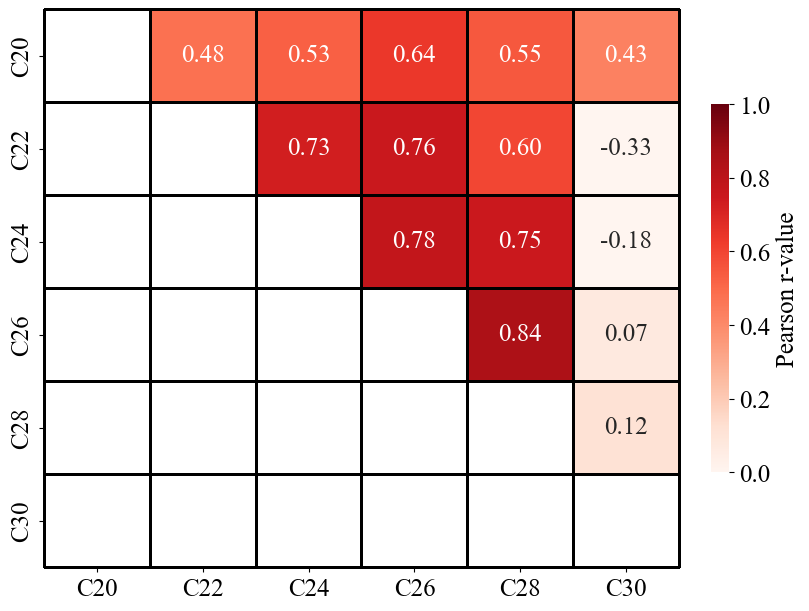

In [ ]:
#load in data
RP_df= pd.read_excel('/Users/leone/OneDrive - University at Buffalo/Red Pond/20251204_LLJ_RedPond_OSIBL  (version 1).xlsx', sheet_name= 'ASE-GC-IRMS')

RP_d2h_df = RP_df[
    [
        'C20 δ2H (‰)',
        'C22 δ2H (‰)',
        'C24 δ2H (‰)',
        'C26 δ2H (‰)',
        'C28 δ2H (‰)',
        'C30 δ2H (‰)'
    ]
]
RP_d2h_df = RP_d2h_df.dropna()
RP_d2h_arr = np.array(RP_d2h_df)

RP_d2h_corr_rvals = Isotope(RP_d2h_arr).corr_rvals()
RP_d2h_corr_pvals = Isotope(RP_d2h_arr).corr_pvals()


# Figure script
fig, axs = plt.subplots(1,1, figsize=(8, 6),layout='constrained')

corr_mask = np.tril(np.ones_like(RP_d2h_corr_rvals, dtype=bool))

ax = axs
sns.heatmap(
    ax=ax, data=RP_d2h_corr_rvals,
    cmap='Reds', mask=corr_mask, annot=True, fmt='.2f', vmin=0, vmax=1,
    linewidths=1, linecolor='black', clip_on=False,
    cbar=True, cbar_kws={'label': "Pearson r-value", 'shrink': 0.66},
    xticklabels=['C20','C22','C24','C26','C28','C30'],
    yticklabels=['C20','C22','C24','C26','C28','C30']
)


figure_qpt_d2h_corr = plt.gcf()

> Yay you did it! Let leonejac@buffalo.edu know if there's any bugs 🐞